<h1><center>Laboratorio 4: EDA en Pandas 🐼</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

### Cuerpo Docente:

- Profesores: Pablo Badilla, Diego Cortez
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Guillermo Cardenas C.
- Nombre de alumno 2: Matías Carvajal P.


### **Link de repositorio de GitHub:** `http://github.com/Wiliwiliwili/MDS7202`


## Reglas:

- **Grupos de 2 personas**
- Asistencia **obligatoria** a instrucciones del lab (viernes 16.15). Luego, pueden quedarse trabajando en las salas o irse.
- **No se revisarán entregas de personas ausentes**. 
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibidas las copias. 
- Pueden usar cualquer matrial del curso que estimen conveniente.

### Objetivos principales del laboratorio

- Aplicar los paradigmas y buenas prácticas de programación vistas hasta este momento.
- Utilizar las funciones de la librería `pandas` para realizar análisis exploratorio de datos
- Aplicar principios de visualización de datos vistos en clases para mostrar patrones en los datos


El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas de `pandas`.

## Descripción del laboratorio.

### Importamos librerias utiles 😸

In [1]:
# Libreria Core del lab.

# Libreria para plotear
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import plotly.express as px
from IPython.display import Markdown, display
from scipy import stats

# Segmentación de Clientes en Tienda de Retail 🛍️

<p align="center">
  <img width=300 src="https://s1.eestatic.com/2018/04/14/social/la_jungla_-_social_299733421_73842361_854x640.jpg">
</p>

## 1.1 Cargar dataset [0.5 puntos]

Mr. Lepin Mora quien es el gerente de una cotizada tienda de retail en Europa, les solicita si pueden analizar los datos de algunas de sus tiendas.

Para esto, el área de ventas les entrega el 2 archivos: `online_retail_II.pickle` y `online_retail_I.pickle`.
- Cargue ambas fuentes y asegúrese que las columnas son del tipo correcto como en el ejemplo de df_retail_1 visualizando los datos para determinar el tipo. Para fechas, puede usar `'datetime64[ns]'`
- Combine los dataframes en uno solo. ¿Qué función debe utilizar en este caso?
- Señale las columnas que componen el dataset combinado, el tipo de variable presente en cada columna y comente que representa cada una de estas.

**Respuesta:**

In [20]:
df_retail_1 = pd.read_pickle("online_retail_I.pickle")
df_retail_1 = df_retail_1.astype(
    {
        "Invoice": "category",
        "StockCode": "category",
        "Description": str,
        "Quantity": int,
        "Price": float,
        "Customer ID": "category",
        "Country": "category",
    }
)
print(df_retail_1.columns)
df_retail_1.head()

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'Price',
       'Customer ID', 'Country'],
      dtype='object')


,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085.0,United Kingdom


In [21]:
df_retail_2 = pd.read_pickle("online_retail_II.pickle")
print(df_retail_2.columns)

df_retail_2 = df_retail_2.astype({"Invoice": "category", "InvoiceDate": "datetime64[ns]"})
df_retail_2.head()

Index(['Invoice', 'InvoiceDate'], dtype='str')


,Invoice,InvoiceDate
0,489434,2009-12-01 07:45:00
1,489435,2009-12-01 07:46:00
2,489436,2009-12-01 09:06:00
3,489437,2009-12-01 09:08:00
4,489438,2009-12-01 09:24:00


In [22]:
df_retail = df_retail_1.merge(df_retail_2, on="Invoice", how="left")
df_retail[~df_retail["Invoice"].duplicated()].head()

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,InvoiceDate
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085.0,United Kingdom,2009-12-01 07:45:00
8,489435,22350,CAT BOWL,12,2.55,13085.0,United Kingdom,2009-12-01 07:46:00
12,489436,48173C,DOOR MAT BLACK FLOCK,10,5.95,13078.0,United Kingdom,2009-12-01 09:06:00
31,489437,22143,CHRISTMAS CRAFT HEART DECORATIONS,6,2.10,15362.0,United Kingdom,2009-12-01 09:08:00
54,489438,21329,DINOSAURS WRITING SET,28,0.98,18102.0,United Kingdom,2009-12-01 09:24:00


## 1.2 Analisís Explotatorio de los Datos [0.5 puntos] 

En base a la primera visualización del dataset, *Don Mora* le solicita que realicen un análisis exploratorio de los datos, para esto les deberán realizar un análisis univariado y multivariado. De la revisión, ustedes deben explicar potenciales anomalías visualizadas y señalar si existe la necesidad de realizar una limpieza de datos.

Explique a que nos referimos con análisis univariable, multivariable y de datos faltantes. ¿Qué beneficios nos otorga estudiar estos datos?. Sea conciso con su respuesta y no escriba mas de 5 líneas para su respuesta.

**Respuesta a la Pregunta:**

> Un análisis univariado estudia cada variable por separado, permitiendo entender la distribución de cada variable e identificar elementos importantes (outliers, errores, elementos más frecuentes, entre otros). Por otro lado, el análisis multivariado estudia la relación entre más de una variable simultaneamente, como podría ser una matriz de correlación de Pearson, coordenadas paralelas o scatter matrix. Por último, es importante verificar si existen valores faltantes (nulos), pues son muy comunes y pueden afectar significativamente los procedimientos posteriores (Fuente: Clase 8, Visualizaciones y EDA).

### 1.2.1 Análisis Univariado [1.5 Puntos]

A continuación, se le presentan dos funciones para analizar los datos que componen un dataframe. La primera de estas es la función ``profile_serie()`` la cual recibe una serie y le entrega un análisis detallado de los datos que conforman dicha serie. 

Ejecute la funcion ``profile_serie()`` sobre cada serie para realizar un análisis univariado de estas. A continuación, comente acerca de el comportamiento de cada variable según las estadísticas descriptivas y los gráficos generados.

In [24]:
from pandas.api.types import is_datetime64_any_dtype, is_numeric_dtype, is_timedelta64_dtype


def profile_serie(serie_in, n_samples=1000, random_state=42):
    serie = serie_in.copy()

    profile = pd.Series(dtype="object")
    profile["Type"] = serie.dtype
    profile = pd.concat([profile, serie.describe()])

    # profile = pd.Series([])

    if is_numeric_dtype(serie):
        profile["Negative"] = (serie < 0).sum()
        profile["Negative (%)"] = str(round((serie < 0).sum() / len(serie) * 100, 2)) + " %"
        profile["Zeros"] = (serie == 0).sum()
        profile["Zeros (%)"] = str(round((serie == 0).sum() / len(serie) * 100, 2)) + " %"
        profile["Kurt"] = serie.kurt()
        profile["Skew"] = serie.skew()

    profile[" "] = " "  # espacio

    profile["Missing cells"] = serie.isnull().sum()
    profile["Missing cells (%)"] = str(round(serie.isnull().sum() / len(serie) * 100, 2)) + " %"
    profile["Duplicate rows"] = serie.duplicated(False).sum()
    profile["Duplicate rows (%)"] = str(round(serie.duplicated(False).sum() / len(serie) * 100, 2)) + " %"
    profile["Total size in memory"] = str(serie.memory_usage(index=True)) + " bytes"

    # profile = pd.concat([profile, description])

    profile = profile.rename(
        index={
            "count": "Number of observations",
            "mean": "Mean",
            "std": "Std",
            "min": "Min",
            "max": "Max",
            "unique": "Unique",
            "top": "Top",
            "freq": "Freq",
        }
    )
    no_outliers_fig = None

    if is_numeric_dtype(serie):
        sampled_serie = serie.sample(n_samples, random_state=random_state)
        fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name} - With Outliers")

        no_outliers = sampled_serie.loc[(np.abs(stats.zscore(sampled_serie)) < 3)]
        # zscore = https://es.wikipedia.org/wiki/Unidad_tipificada

        no_outliers_fig = px.histogram(no_outliers, marginal="box", title=f"{serie.name} - Without Outliers")

    elif is_datetime64_any_dtype(serie) or is_timedelta64_dtype(serie):
        sampled_serie = serie.sample(n_samples, random_state=random_state)
        fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name}")

    else:
        count = serie.value_counts()[0:100].reset_index().rename(columns={"count": "Count"})
        fig = px.bar(
            x=count[serie.name].astype(str),
            y=count["Count"],
            title=f"100 Most common categories of {serie.name}",
        )
    display(Markdown(f"## {serie.name} Profile"))
    display(profile)
    fig.show()

    if no_outliers_fig:
        no_outliers_fig.show()

    # return fig, profile

    Se debe considerar que el presente análisis exploratorio se basa en una muestra aleatoria de 1000 observaciones. Por lo tanto, los resultados corresponden a patrones preliminares que deben ser validados sobre el conjunto completo de datos.

In [25]:
profile_serie(df_retail["Price"])

## Price Profile

Type                            float64
Number of observations         525461.0
Mean                           4.688834
Std                          146.126914
Min                           -53594.36
25%                                1.25
50%                                 2.1
75%                                4.21
Max                            25111.09
Negative                              3
Negative (%)                      0.0 %
Zeros                              3687
Zeros (%)                         0.7 %
Kurt                       64868.344873
Skew                        -140.768446
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   524485
Duplicate rows (%)              99.81 %
Total size in memory      4203820 bytes
dtype: object

    Se identifica un outlier cercano a $1269.51, considerablemente alejado del resto de la distribución, el que entorpece la visualización de éste. Sin considerarlo, se ve que los precios siguen una distribución asimetrica, con cola derecha y una mayor densidad entre $0.5 y $1.49. La cola derecha se extiende hasta aproximadamente $20, mientras que entre $20 y $122.49 los valores son más escasos. Por ende, los precios de la tienda en general son bajos, concentrandose entre $1.25 y $4.21 (rango intercuartil).

In [28]:
profile_serie(df_retail["Invoice"])

## Invoice Profile

Type                           category
Number of observations           525461
Unique                            28816
Top                              537434
Freq                                675
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   517456
Duplicate rows (%)              98.48 %
Total size in memory      2338390 bytes
dtype: object

    Se puede ver que la mayor densidad se alcanza aproximadamente en las facturas 537434 y 537638 con una frecuencia de 675 y 652. Además, la frecuencia de las 100 facturas más frecuentes oscila entre 256 y 675. Con esto, se puede ver que cada factura incluye muchos elementos (675 como máximo), lo que podría indicar que se trata de una tienda mayorista principalmente.

In [29]:
profile_serie(df_retail["StockCode"])

## StockCode Profile

Type                           category
Number of observations           525461
Unique                             4632
Top                              85123A
Freq                               3516
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   525026
Duplicate rows (%)              99.92 %
Total size in memory      1220246 bytes
dtype: object

    Asumiendo que StockCode identifica cada producto, se observa que el código 85123A presenta la mayor frecuencia de aparición (3516 registros), seguido por otros productos con frecuencias considerablemente menores, como el segundo más frecuente con 2221 registros. El gráfico sugiere que la frecuencia disminuye de forma gradual y, por ende, muchos productos tienen frecuencias cercanas.

In [33]:
profile_serie(df_retail["Description"])

## Description Profile

Type                                                     str
Number of observations                                522533
Unique                                                  4681
Top                       WHITE HANGING HEART T-LIGHT HOLDER
Freq                                                    3549
                                                            
Missing cells                                           2928
Missing cells (%)                                     0.56 %
Duplicate rows                                        525198
Duplicate rows (%)                                   99.95 %
Total size in memory                           4203820 bytes
dtype: object

    El histograma de Descripciones muestra una alta frecuencia para el ítem "White Hanging Heart T-light Holder" (3549), valor comparable al observado en el StockCode más frecuente. Esta similitud sugiere una posible correspondencia entre Description y StockCode, considerando que ambos podrían estar representando el producto. No obstante, esta relación no puede confirmarse a partir de un análisis univariado, se debería realizar un análisis multivariado para verificarlo.

In [31]:
profile_serie(df_retail["Quantity"])

## Quantity Profile

Type                              int64
Number of observations         525461.0
Mean                          10.337667
Std                           107.42411
Min                             -9600.0
25%                                 1.0
50%                                 3.0
75%                                10.0
Max                             19152.0
Negative                          12326
Negative (%)                     2.35 %
Zeros                                 0
Zeros (%)                         0.0 %
Kurt                        6277.666908
Skew                          36.044617
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   525122
Duplicate rows (%)              99.94 %
Total size in memory      4203820 bytes
dtype: object

    El boxplot de la variable Quantity muestra que el 50% de los datos se concentra entre 1 y 11 unidades (rango intercuartílico). Por sobre el tercer cuartil se observa una dispersión considerable, con valores que se extienden hasta aproximadamente 100 unidades sin considerar outliers, mientras que al incluirlos se alcanzan máximos cercanos a 567. A su vez, por debajo del primer cuartil se identifican valores negativos, los cuales podrían estar asociados a devoluciones o cancelaciones de productos, aunque su validez debería confirmarse en un análisis multivariado, pues también podría tratarse de un error en el ingreso de los datos.

In [32]:
profile_serie(df_retail["Customer ID"])

## Customer ID Profile

Type                           category
Number of observations         417534.0
Unique                           4383.0
Top                             14911.0
Freq                             5710.0
                                       
Missing cells                    107927
Missing cells (%)               20.54 %
Duplicate rows                   525327
Duplicate rows (%)              99.97 %
Total size in memory      1086118 bytes
dtype: object

    El histograma de CustomerID muestra que existen clientes con una frecuencia mayor al resto, destacando los IDs 14911, 14606 y 12748, con 5710, 5114 y 3927 registros respectivamente. Esto indica que ciertos clientes participan en un número considerablemente mayor de registros dentro del dataset de la tienda. Por otra parte, el resto de los clientes presenta una disminución gradual en sus frecuencias, evidenciando un comportamiento similar al observado en variables como StockCode.

In [36]:
profile_serie(df_retail["Country"])

## Country Profile

Type                            category
Number of observations            525461
Unique                                40
Top                       United Kingdom
Freq                              485852
                                        
Missing cells                          0
Missing cells (%)                  0.0 %
Duplicate rows                    525461
Duplicate rows (%)               100.0 %
Total size in memory        526985 bytes
dtype: object

    El histograma de Country evidencia una alta concentración de registros en United Kingdom, con cerca de 500 000 observaciones, muy por encima del resto de los países, los cuales no superan las 10 000. En particular, la mayoría de los países dentro de los más frecuentes presenta menos de 1 000 registros. Esta marcada asimetría sugiere que la actividad de la tienda está fuertemente concentrada en un solo país, lo que podría indicar que la tienda opera principalmente en Reino Unido o que este constituye su mercado principal.

In [37]:
profile_serie(df_retail["InvoiceDate"])

## InvoiceDate Profile

Type                                     datetime64[ns]
Number of observations                           525461
Mean                      2010-06-28 11:37:36.619958528
Min                                 2009-12-01 07:45:00
25%                                 2010-03-21 12:20:00
50%                                 2010-07-06 09:51:00
75%                                 2010-10-15 12:45:00
Max                                 2010-12-09 20:01:00
                                                       
Missing cells                                         0
Missing cells (%)                                 0.0 %
Duplicate rows                                   520408
Duplicate rows (%)                              99.04 %
Total size in memory                      4203820 bytes
dtype: object

    En el gráfico de la variable InvoiceDate, se observa que la muestra contiene registros desde finales de 2009 hasta finales de 2010, lo que sugiere una cobertura aproximada de un año. Asimismo, se aprecia un aumento en la frecuencia de transacciones durante el mes de noviembre, mientras que el resto del período presenta un comportamiento más oscilante, con variaciones moderadas en el número de registros.

### 1.2.2 Análisis Multivariado y Datos Faltantes [1 ptos]

En segundo lugar encontrará la función ``profile_df()`` que recibe un dataframe como entrada y realiza un análisis bivariado de todas las variables numéricas que conforman el dataframe, un analisis de la correlación de Pearson entre las variables numericas del dataframe y la matriz de datos faltantes.

Utilice esta función en el dataframe. Comente sobre los patrones que observa. Luego responda:
- Existen correlaciones relevantes observadas?
- Qué aspectos revelan estos gráficos acerca de la limpieza de los datos?

In [44]:
def profile_df(dataframe_in):
    df = dataframe_in.copy()

    list_type = []
    for col in list(df.columns):
        if is_numeric_dtype(df[col]) or is_datetime64_any_dtype(df[col]) or is_timedelta64_dtype(df[col]):
            list_type.append(col)

    display(Markdown("## Bivariant Analysis:"))
    for i in range(len(list_type)):
        for j in range(i + 1, len(list_type)):
            plt.scatter(df[list_type[i]], df[list_type[j]])
            plt.xlabel(list_type[i])
            plt.ylabel(list_type[j])
            plt.title(f"{list_type[i]} v/s {list_type[j]}")
            plt.show()

    display(Markdown("## Correlation:"))
    fig_corr = px.imshow(df[list_type].corr())
    fig_corr.show()

    display(Markdown("## Missing Matrix:"))
    fig, ax = plt.subplots(figsize=[15, 10])
    msno.matrix(df, ax=ax, sparkline=False)

## Bivariant Analysis:

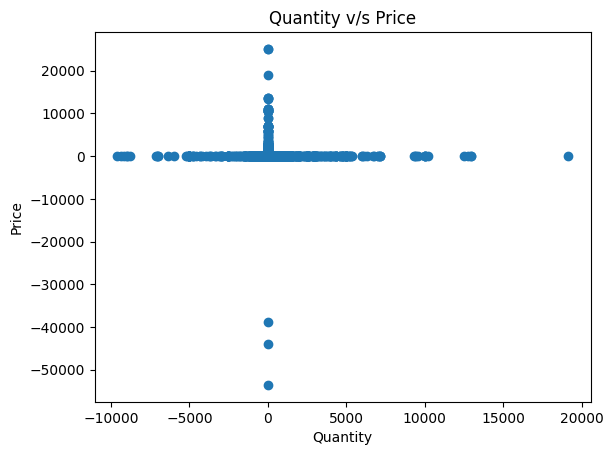

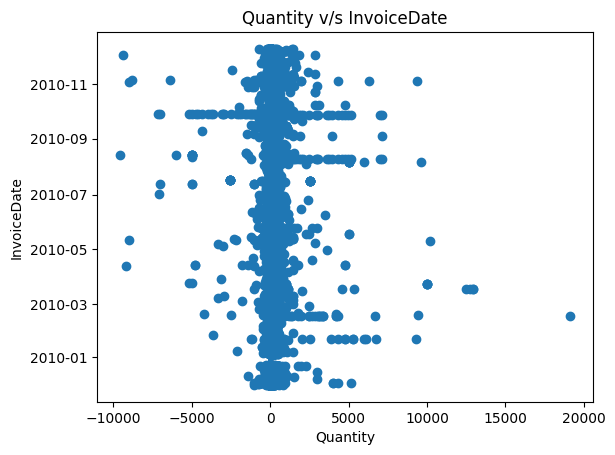

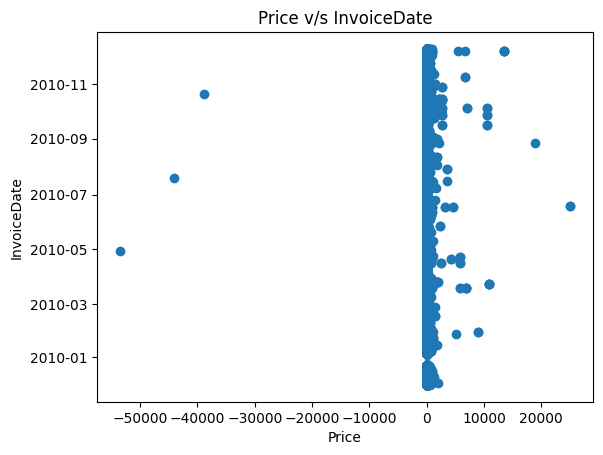

## Correlation:

## Missing Matrix:

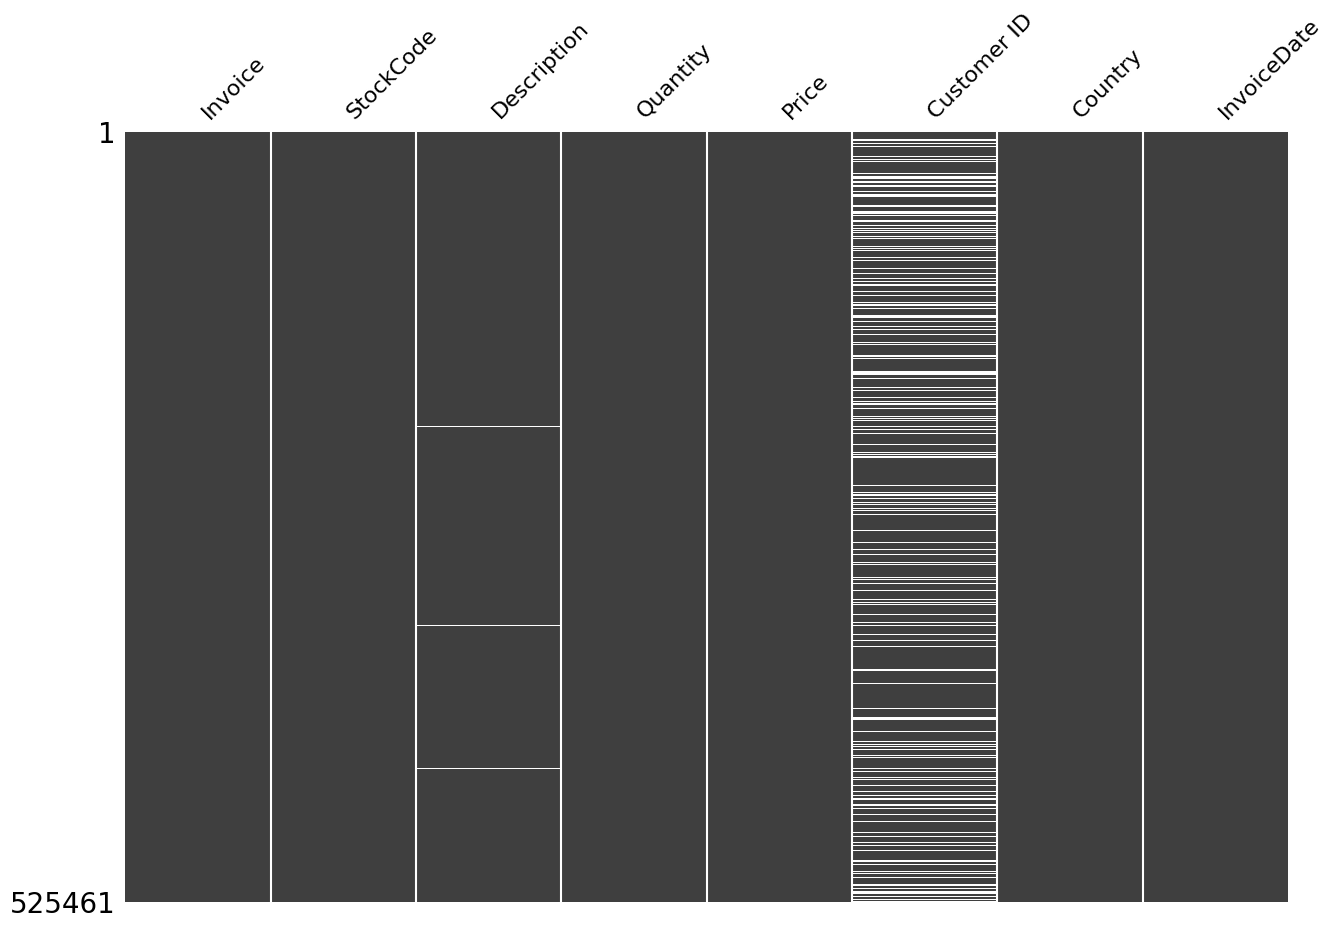

In [45]:
profile_df(df_retail)

    En el análisis bivariado se observa que la presencia de valores extremos en Price distorsiona la visualización, expandiendo la escala del eje y haciendo que la mayoría de los datos se concentre visualmente en torno a cero. Esto dificulta la identificación de patrones entre Price y Quantity / InvoiceDate.

    De manera similar, en la relación entre Quantity e InvoiceDate, se aprecia una alta concentración de valores cercanos a cero, junto con la presencia de cantidades tanto positivas como negativas, que podrían incinuar ciertas concentraciones de actividad hacia los últimos meses de 2010.

    Finalmente, la matriz de datos faltantes muestra una baja proporción de datos ausentes en Description, mientras que CostumerID presenta una cantidad considerablemente mayor, donde los valores faltantes se distribuyen a lo largo de toda la columna.

    En relación con las preguntas del enunciado, no se observan correlaciones lineales significativas entre las variables analizadas. Asimismo, los gráficos evidencian la presencia de valores extremos que afectan la escala y dificultan la correcta interpretación visual de los datos. En este sentido, se hace necesario aplicar un proceso de limpieza de datos, con el objetivo de mejorar la visualización y permitir un análisis multivariado representativo.

### 1.2.3 Limpieza de Datos [1 pto]

Como pudo ver en las secciones anteriores, los datos presentan valores erroneos, es por esto que se le solicita que realice una función que permita limpiar el dataset. Realice esta función en base observaciones propias y considere como **imposible tener cantidades negativas** en las ventas. Investigue sobre métodos para eliminar outliers usando pandas

Una vez realizada la función, realice nuevamente el análisis exploratorio y comente las principales diferencias.

**Respuesta:**

In [50]:
def limpiar_dataset(dataframe, columns=None, only_sales: bool = True, drop_nulls: bool = True):
    """
    Limpia el dataset de transacciones eliminando outliers mediante IQR.

    :param dataframe: DataFrame de pandas
    :param columns: lista de columnas a limpiar
    :param only_sales: si True, filtra solo ventas (Quantity > 0 y Price > 0)
    :param drop_nulls: si True, filtra solo datos no nulos
    :return: DataFrame limpio y máscara empleada
    """
    if columns is None:
        columns = ["Price", "Quantity"]

    df = dataframe.copy()

    # Filtrar solo valores no nulos
    if drop_nulls:
        df = df.dropna()

    # Filtrar solo ventas
    if only_sales:
        df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]

    mask = np.ones(len(df), dtype=bool)

    for column in columns:
        if column not in df.columns:
            raise ValueError(f"La columna {column} no existe en el dataset.")

        q1 = df[column].quantile(0.25)
        q3 = df[column].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        mask = mask & ((df[column] >= lower_bound) & (df[column] <= upper_bound))

    return df[mask], mask

## Bivariant Analysis:

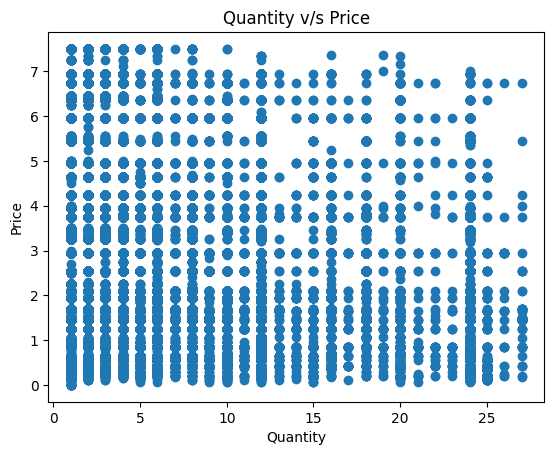

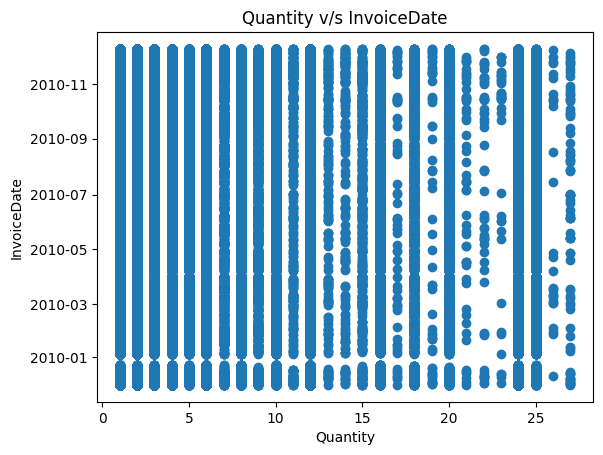

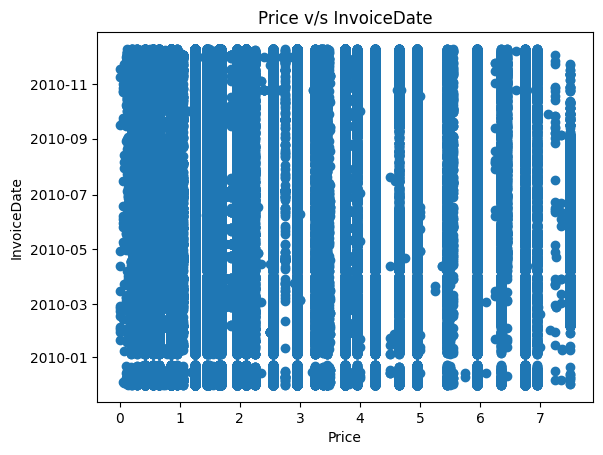

## Correlation:

## Missing Matrix:

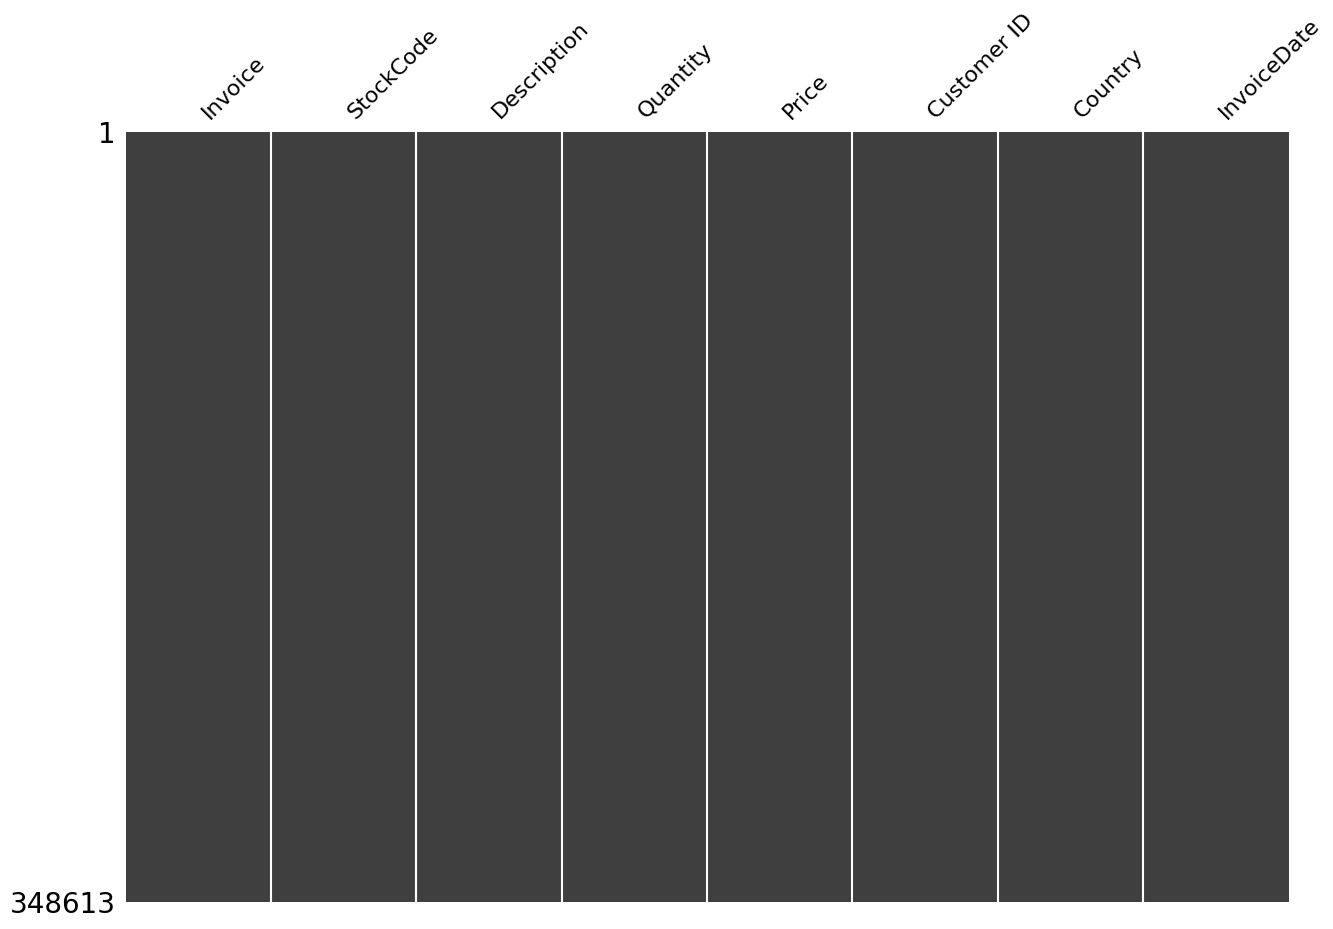

In [51]:
df_retail_clean, _ = limpiar_dataset(df_retail, columns=["Price", "Quantity"], only_sales=True, drop_nulls=True)
profile_df(df_retail_clean)

    En el primer gráfico Quantity v/s Price, donde originalmente no se apreciaba una relación clara, ahora se observa una leve tendencia en la esquina superior derecha: las cantidades de venta altas presentan una menor frecuencia de precios elevados. Este comportamiento resulta coherente con lo esperado en un contexto real, ya que, si bien el precio depende del producto, es habitual que las compras en grandes volúmenes se realicen bajo esquemas mayoristas, donde el precio unitario tiende a disminuir.

    En el segundo gráfico Quantity v/s InvoiceDate se visualiza un patrón relativamente uniforme de las cantidades vendidas a lo largo de los distintos meses. No obstante, se observan sutilezas en ciertas cantidades específicas (por ejemplo, 22, 23 y 26), las cuales parecen concentrarse con mayor frecuencia en determinados períodos del año. En contraste, en el gráfico Price v/s InvoiceDate no se identifican interacciones relevantes entre el precio y el tiempo, lo que sugiere una baja dependencia temporal del precio.

    Respecto a las correlaciones, inicialmente la correlación lineal entre Price y Quantity era prácticamente nula. Sin embargo, tras la limpieza de los datos, se evidencia una correlación inversa entre ambas variables, lo cual es consistente con lo observado en el análisis bivariado. Finalmente, al eliminar los datos faltantes, se obtiene una matriz completamente rellena. Aun así, a nivel del análisis numérico realizado, no se observan diferencias significativas entre considerar o excluir dichos valores, tal como se muestra en los resultados posteriores.

    Fuentes para Limpieza de Outliers:
    - https://www.geeksforgeeks.org/pandas/handling-outliers-with-pandas/
    - https://medium.com/@heyamit10/pandas-outlier-detection-techniques-e9afece3d9e3


## Bivariant Analysis:

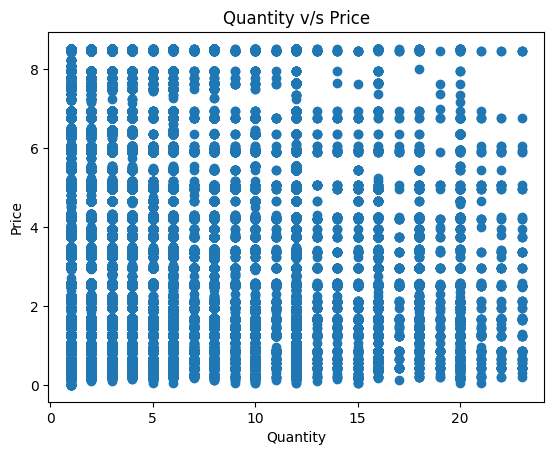

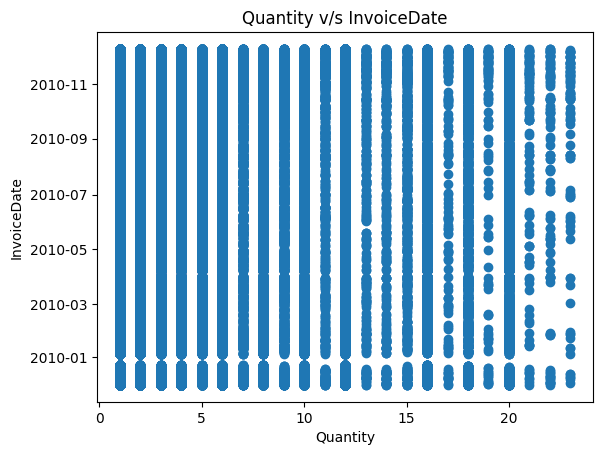

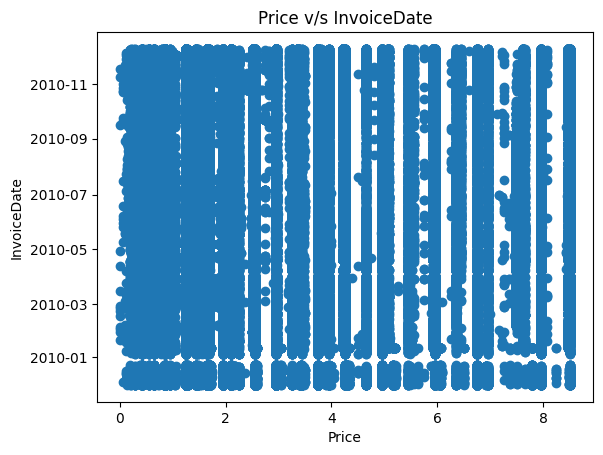

## Correlation:

## Missing Matrix:

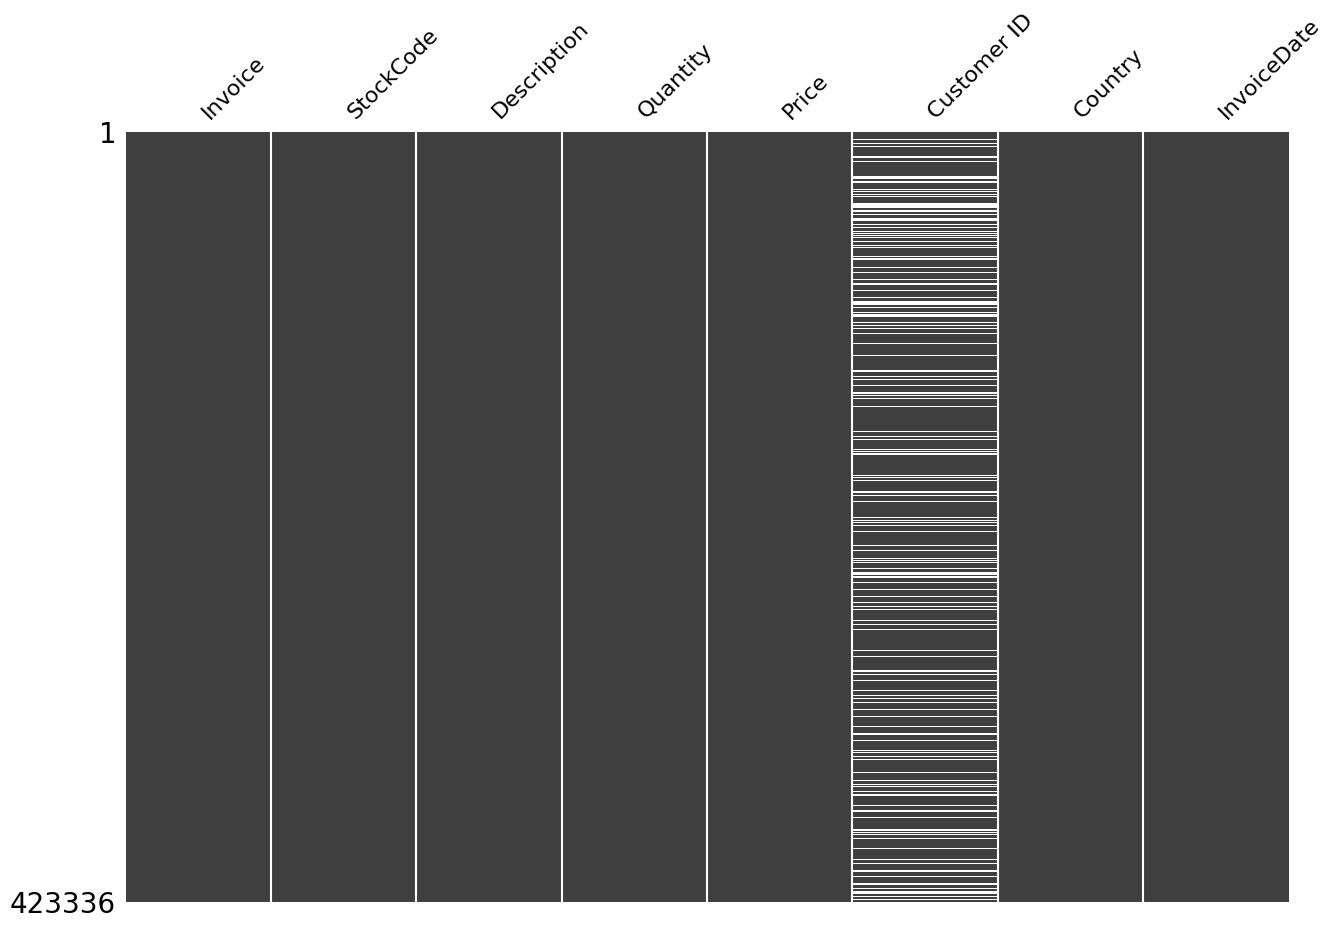

In [52]:
df_retail_clean_test, _ = limpiar_dataset(df_retail, columns=["Price", "Quantity"], only_sales=True, drop_nulls=False)
profile_df(df_retail_clean_test)

### 1.2.4 Obtención de TOPs [0.75 ptos]

Sin considerar los comentarios realizados en la sección 1.2 , *Don Mora* les pide obtener el **Top de 30 productos que generan más ganancias** para la tienda de retail. Deben considerar todo el registro temporal presente en el dataset y entregar la información en un gráfico de barras de los ingresos/cantidades v/s el nombre de los productos (Utilice `plotly`). ¿Los artículos más vendidos son los mismos que generan más ganancias?, Comente los resultados obtenidos.

**Resultados:**

    Primero se verifica que el supuesto de que cada StockCode tiene una sola Descripción es válido, notando que se cumple en su mayoría.

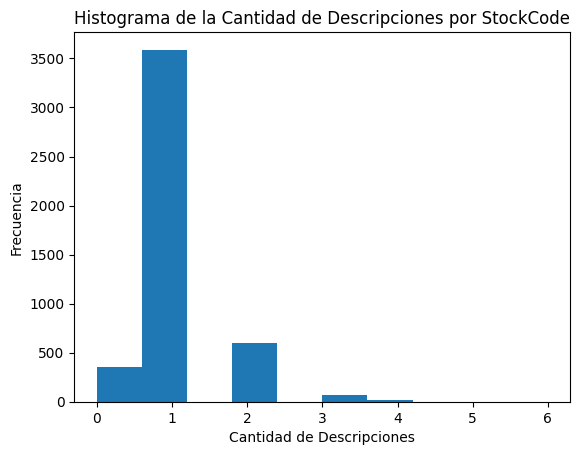

In [62]:
stock_vs_desc = df_retail.groupby("StockCode")["Description"].nunique().reset_index()
stock_vs_desc.hist()
plt.title("Histograma de la Cantidad de Descripciones por StockCode")
plt.xlabel("Cantidad de Descripciones")
plt.ylabel("Frecuencia")
plt.grid()
plt.show()

In [64]:
df_tops = df_retail.copy()
df_tops["Ganancias"] = df_tops["Price"] * df_tops["Quantity"]  # ganancias = precio * cantidad
df_tops = df_tops.groupby("StockCode").agg(
    {"Ganancias": "sum", "Quantity": "sum"}
)  # agrupamos por producto y sumamos cantidad y ganancias
df_tops = df_tops.sort_values("Ganancias", ascending=False).head(30)  # ordenamos y tomamos el top 30
display(df_tops)

,Ganancias,Quantity
StockCode,,
22423,163051.46,12784
85123A,155825.52,57236
DOT,116401.99,1231
85099B,88922.48,48376
84879,72454.12,44484
22086,57870.20,17023
47566,49645.52,9269
84347,47672.49,13048
POST,46092.36,3754


In [67]:
descriptions = df_retail[["StockCode", "Description"]].drop_duplicates(
    subset="StockCode"
)  # dataframe de pares producto - descripción
df_tops_desc = df_tops.merge(descriptions, on="StockCode", how="left")  # join del top con las descripciones
display(df_tops_desc)

,StockCode,Ganancias,Quantity,Description
0,22423,163051.46,12784,REGENCY CAKESTAND 3 TIER
1,85123A,155825.52,57236,WHITE HANGING HEART T-LIGHT HOLDER
2,DOT,116401.99,1231,DOTCOM POSTAGE
3,85099B,88922.48,48376,JUMBO BAG RED WHITE SPOTTY
4,84879,72454.12,44484,ASSORTED COLOUR BIRD ORNAMENT
5,22086,57870.20,17023,PAPER CHAIN KIT 50'S CHRISTMAS
6,47566,49645.52,9269,PARTY BUNTING
7,84347,47672.49,13048,ROTATING SILVER ANGELS T-LIGHT HLDR
8,POST,46092.36,3754,POSTAGE
9,21843,42333.85,3955,RETRO SPOT CAKE STAND


In [69]:
display(Markdown("## **Top de 30 productos que generan más ganancias**:"))
fig = px.bar(
    df_tops_desc,
    x="Ganancias",
    y="Description",
    color="Quantity",
)
fig.update_layout(yaxis={"categoryorder": "total ascending"})
fig.show()

## **Top de 30 productos que generan más ganancias**:

    Los artículos más vendidos no son necesariamente aquellos que generan mayores ganancias. En efecto, el producto con mayor ganancia total presenta una de las cantidades vendidas más bajas (12k), mientras que el segundo producto con mayor ganancia sí corresponde a uno de los más vendidos (57k). Este resultado sugiere que no existe una relación explícita y directa entre la cantidad de ventas y las ganancias obtenidas, ya que el precio unitario juega un rol determinante en dicha relación. De este modo, un producto con un precio elevado, aun cuando se venda en menor volumen, puede generar mayores ingresos que productos de bajo precio con altas cantidades vendidas.

### 1.2.5 Visualización del registro temporal [0,75 ptos]

El dueño del retail en su afán por saber más sobre los datos de su firma les solicita que grafiquen las ventas respecto al tiempo. Con esto les aclara que durante el día tienen muchas variaciones en sus ventas, por lo que les recomienda que consideren el registro temporal como `año-mes-día`. ¿Es posible observar datos extraños?, Comente lo que observa del gráfico.

In [92]:
def plot_ventas(dataframe):
    df = dataframe.copy()
    df["Date"] = df["InvoiceDate"].dt.date  # pasar a año-mes-día
    df["Ganancias"] = df["Price"] * df["Quantity"]

    daily_sales = df.groupby("Date", as_index=False).agg({"Ganancias": "sum"})

    display(Markdown("## Ventas respecto al tiempo:"))
    fig = px.scatter(daily_sales, x="Date", y="Ganancias")

    fig.show()

In [93]:
plot_ventas(df_retail)

## Ventas respecto al tiempo:

    En primer lugar, consideramos por ventas diarias las ganancias generadas en cada día, calculadas como el producto entre precio y cantidad vendida. Alternativamente, las ventas podrían haberse definido como el número de transacciones diarias o mediante Quantity. Sin embargo, se optó por utilizar las ganancias, ya que esta métrica resulta consistente con el análisis previo y representa de mejor manera el desempeño económico diario de la tienda.

    A partir del gráfico, se observan algunos días con ganancias negativas, lo que sugiere la existencia de pérdidas en dichas fechas. En particular, destacan el 29 de abril, el 19 de julio y el 27 de agosto, los cuales podrían estar asociados a devoluciones o cancelaciones de ventas. Por otro lado, durante el mes de noviembre se registran las ganancias diarias más altas, lo que indica un aumento significativo en las ventas durante ese período. En general, el gráfico evidencia que las ventas presentan una alta variabilidad entre días, sin una tendencia temporal claramente definida.

# Conclusión
Eso ha sido todo para el lab de hoy, recuerden que el laboratorio tiene un plazo de entrega de una semana. Cualquier duda del laboratorio, no duden en contactarnos por mail o U-cursos.

![Gracias Totales!](https://i.pinimg.com/originals/65/ae/27/65ae270df87c3c4adcea997e48f60852.gif "bruno")


<br>
<center>
<img src="https://i.kym-cdn.com/photos/images/original/001/194/195/b18.png" width=100 height=50 />
</center>
<br>

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=87110296-876e-426f-b91d-aaf681223468' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>